---
# Part 1: Introduction

# Association Rule Mining
### Finding hidden patterns in FreshBasket orders

## The problem

FreshBasket processes thousands of daily orders. Useful patterns — which items are bought together — are buried inside, invisible to any human reading logs. Association rule mining surfaces them automatically.

## Can you spot the pattern?

20 FreshBasket orders below. Try to find which items consistently appear together:

In [1]:
transactions = [
    ["basmati rice", "toor dal", "refined oil", "turmeric powder"],
    ["maggi noodles", "tomato ketchup", "butter", "bread"],
    ["basmati rice", "toor dal", "mustard seeds", "ghee", "turmeric powder"],
    ["maggi noodles", "tomato ketchup", "bread", "cheese"],
    ["basmati rice", "toor dal", "refined oil", "mustard seeds"],
    ["maggi noodles", "tomato ketchup", "cheese", "eggs", "butter"],
    ["basmati rice", "toor dal", "ghee", "turmeric powder"],
    ["maggi noodles", "tomato ketchup", "eggs", "bread"],
    ["whole wheat atta", "besan", "refined oil", "ghee"],
    ["basmati rice", "turmeric powder", "ghee", "mustard seeds"],
    ["maggi noodles", "tomato ketchup", "turmeric powder", "refined oil"],
    ["whole wheat atta", "besan", "turmeric powder", "mustard seeds"],
    ["basmati rice", "toor dal", "besan", "ghee"],
    ["turmeric powder", "ghee", "mustard seeds", "refined oil"],
    ["maggi noodles", "bread", "butter", "eggs"],
    ["basmati rice", "whole wheat atta", "besan", "toor dal"],
    ["toor dal", "turmeric powder", "ghee", "mustard seeds"],
    ["maggi noodles", "tomato ketchup", "besan", "butter"],
    ["basmati rice", "toor dal", "refined oil", "turmeric powder", "ghee"],
    ["whole wheat atta", "ghee", "refined oil", "mustard seeds"],
]

n_items = len(set(item for t in transactions for item in t))
print(f"{len(transactions)} orders | {n_items} unique products")
print(f"Basket sizes: min={min(len(t) for t in transactions)}, "
      f"max={max(len(t) for t in transactions)}, "
      f"avg={sum(len(t) for t in transactions)/len(transactions):.1f}")


20 orders | 14 unique products
Basket sizes: min=4, max=5, avg=4.2


## Item Frequency

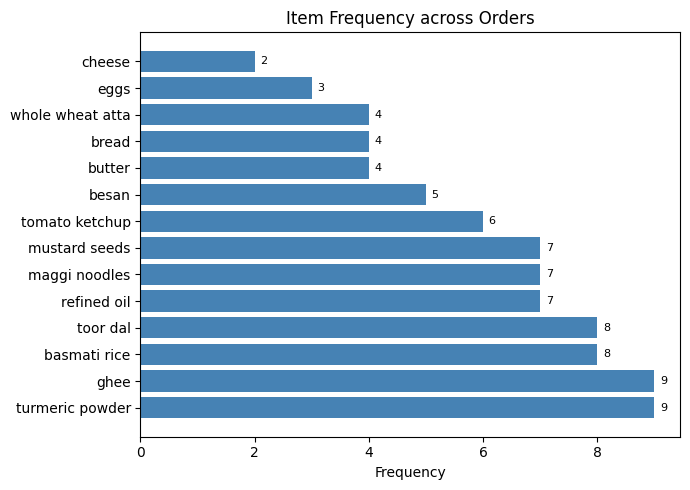

In [2]:
from collections import Counter
import matplotlib.pyplot as plt

item_counts = Counter(item for t in transactions for item in t)
items_sorted, freqs = zip(*sorted(item_counts.items(), key=lambda x: -x[1]))

plt.figure(figsize=(7, 5))
plt.barh(items_sorted, freqs, color="steelblue")
#plt.invert_yaxis()
plt.xlabel("Frequency")
plt.title("Item Frequency across Orders")
for i, v in enumerate(freqs):
    plt.text(v + 0.1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()


**Basmati rice, toor dal** and **tomato ketchup** dominate — likely candidates for strong rules.

## Co-occurrence Heatmap

How many times did each pair of items appear in the same basket?

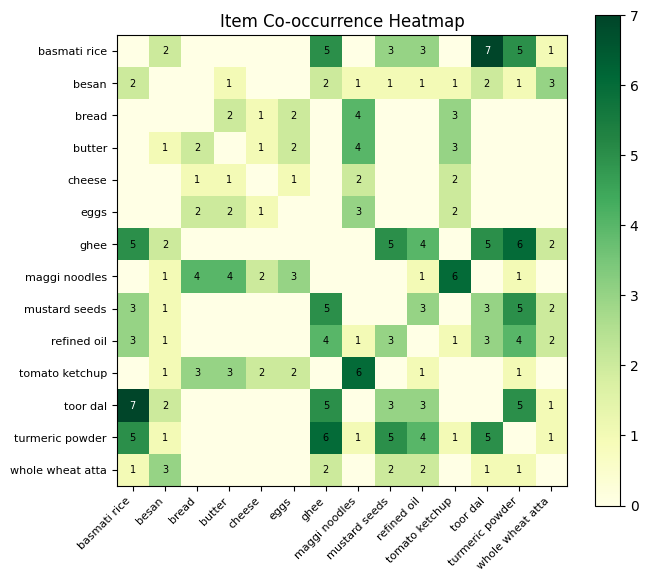

In [3]:
from itertools import combinations
import numpy as np

unique_items = sorted(item_counts.keys())
idx = {item: i for i, item in enumerate(unique_items)}
n = len(unique_items)

co_matrix = np.zeros((n, n), dtype=int)
for t in transactions:
    for a, b in combinations(t, 2):
        co_matrix[idx[a]][idx[b]] += 1
        co_matrix[idx[b]][idx[a]] += 1

plt.figure(figsize=(7, 6))
im = plt.imshow(co_matrix, cmap="YlGn") #Blues
plt.xticks(range(n), unique_items, rotation=45, ha="right", fontsize=8)
plt.yticks(range(n), unique_items, fontsize=8)
plt.title("Item Co-occurrence Heatmap")
plt.colorbar(im)
for i in range(n):
    for j in range(n):
        if co_matrix[i, j] > 0:
            plt.text(j, i, co_matrix[i, j], ha="center", va="center", fontsize=7,
                     color="white" if co_matrix[i, j] > 6 else "black")
plt.tight_layout()
plt.show()


Two bright clusters stand out — **basmati rice ↔ toor dal** and **maggi noodles ↔ tomato ketchup**. These are the rules the algorithm will find. But what happens at scale?

## Why brute force doesn't scale

**Pairs in matrix = I × (I − 1) / 2** — with 1,000 products that's nearly 500,000 pairs. The plot below shows how fast this grows:

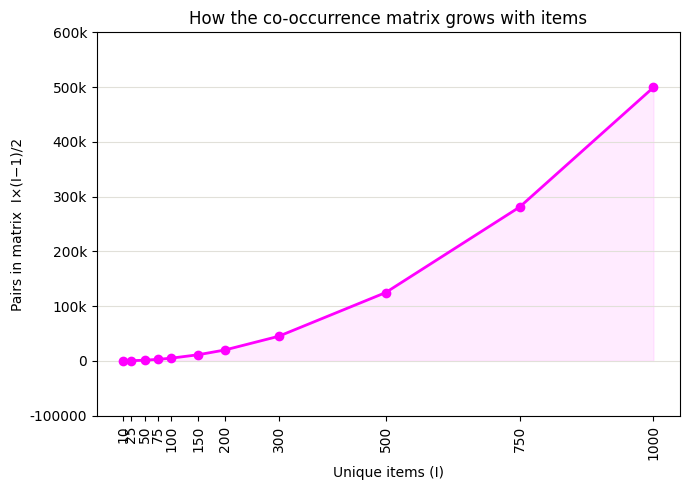

In [4]:
import matplotlib.pyplot as plt
import numpy as np

items = [10, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000]
pairs = [i * (i - 1) // 2 for i in items]

plt.figure(figsize=(7, 5))
plt.plot(items, pairs, color="magenta", linewidth=2, marker="o",
         markersize=5, markerfacecolor="magenta", markeredgewidth=2)
plt.fill_between(items, pairs, alpha=0.08, color="magenta") #steelblue
plt.xlabel("Unique items (I)")
plt.ylabel("Pairs in matrix  I×(I−1)/2")
plt.title("How the co-occurrence matrix grows with items")
plt.xticks(items, rotation=90)
plt.yticks(plt.yticks()[0], [f"{int(y/1000)}k" if y >= 1000 else str(int(y))
                              for y in plt.yticks()[0]])
plt.grid(axis="y", color="#e1e0d9")
plt.tight_layout()
plt.show()

Matrix size grows **quadratically** with items, linearly with transactions. This is why **Apriori** exists — it skips combinations guaranteed to be infrequent.

---
# Part 2: Concepts

# Association Rule Mining — Part 2
### Understanding Support, Confidence and Lift

The co-occurrence heatmap from Part 1 shows which items appear together — but "frequently" is vague. **Support**, **Confidence**, and **Lift** turn that visual hunch into measurable, actionable numbers.

In [5]:
transactions = [
    # basmati rice almost always with toor dal
    ["basmati rice", "toor dal", "ghee", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "mustard seeds"],
    ["basmati rice", "toor dal", "ghee", "mustard seeds"],
    ["basmati rice", "toor dal", "turmeric powder", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "besan"],
    ["basmati rice", "toor dal", "mustard seeds", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "ghee"],
    ["basmati rice", "toor dal", "turmeric powder", "besan"],
    ["basmati rice", "toor dal", "ghee", "refined oil"],
    ["basmati rice", "toor dal", "mustard seeds", "besan"],
    ["basmati rice", "toor dal", "turmeric powder", "mustard seeds"],
    ["basmati rice", "toor dal", "besan", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "refined oil", "besan", "turmeric powder"],
    # maggi noodles mostly with tomato ketchup, but ketchup also popular alone
    ["maggi noodles", "tomato ketchup", "butter", "bread"],
    ["maggi noodles", "tomato ketchup", "eggs", "bread"],
    ["maggi noodles", "tomato ketchup", "cheese", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "eggs"],
    ["maggi noodles", "tomato ketchup", "butter", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "cheese"],
    ["maggi noodles", "tomato ketchup", "bread", "butter"],
    ["maggi noodles", "butter", "bread", "eggs"],
    ["maggi noodles", "cheese", "eggs", "bread"],
    ["tomato ketchup", "bread", "butter", "eggs"],
    ["tomato ketchup", "cheese", "bread", "butter"],
    ["tomato ketchup", "eggs", "cheese", "bread"],
    ["tomato ketchup", "butter", "bread", "sugar"],
    ["tomato ketchup", "bread", "eggs", "sugar"],
    ["tomato ketchup", "cheese", "butter", "sugar"],
    ["tomato ketchup", "eggs", "butter", "sugar"],
    ["tomato ketchup", "bread", "cheese", "sugar"],
    ["tomato ketchup", "butter", "eggs", "sugar"],
    ["tomato ketchup", "bread", "butter", "cheese"],
    # saffron always with cardamom but both rare
    ["saffron", "cardamom", "ghee", "sugar"],
    ["saffron", "cardamom", "sugar", "whole wheat atta"],
    ["saffron", "cardamom", "ghee", "whole wheat atta"],
    ["saffron", "cardamom", "sugar", "ghee"],
    # whole wheat atta and sugar — no real link
    ["whole wheat atta", "besan", "refined oil", "ghee"],
    ["whole wheat atta", "besan", "mustard seeds", "refined oil"],
    ["whole wheat atta", "besan", "ghee", "turmeric powder"],
    ["whole wheat atta", "sugar", "ghee", "butter"],
    ["whole wheat atta", "sugar", "eggs", "butter"],
    ["whole wheat atta", "besan", "refined oil", "mustard seeds"],
    ["whole wheat atta", "ghee", "besan", "turmeric powder"],
    ["whole wheat atta", "ghee", "refined oil", "mustard seeds"],
    ["whole wheat atta", "besan", "turmeric powder", "mustard seeds"],
    ["sugar", "butter", "eggs", "bread"],
    ["sugar", "butter", "bread", "cheese"],
    ["sugar", "ghee", "eggs", "bread"],
    # bread and besan — rarely together
    ["bread", "butter", "eggs", "sugar"],
    ["bread", "butter", "cheese", "eggs"],
    ["bread", "eggs", "butter", "whole wheat atta"],
    ["bread", "cheese", "butter", "sugar"],
    ["bread", "eggs", "whole wheat atta", "sugar"],
    ["bread", "tomato ketchup", "butter", "eggs"],
    ["bread", "besan", "butter", "eggs"],
    ["bread", "besan", "ghee", "sugar"],
    ["bread", "cheese", "sugar", "butter"],
    ["besan", "ghee", "refined oil", "turmeric powder"],
    ["besan", "refined oil", "mustard seeds", "ghee"],
    ["besan", "ghee", "turmeric powder", "mustard seeds"],
]

rules = [
    (["basmati rice"],     ["toor dal"],        "basmati rice → toor dal"),
    (["maggi noodles"],    ["tomato ketchup"],  "maggi noodles → tomato ketchup"),
    (["saffron"],          ["cardamom"],        "saffron → cardamom"),
    (["whole wheat atta"], ["sugar"],           "whole wheat atta → sugar"),
    (["bread"],            ["besan"],           "bread → besan"),
]

print(f"Total transactions: {len(transactions)}")


Total transactions: 64


## Support

How often do both items appear together across all orders?

> Support(A → B) = Orders containing both A and B / Total orders

Low support means a rule fires too rarely to act on.

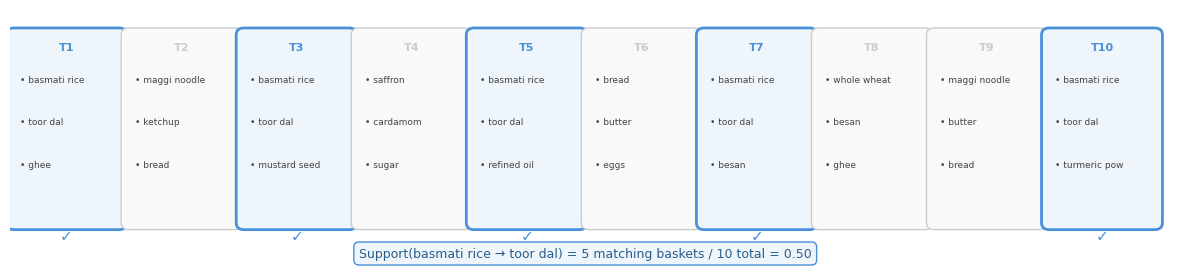

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Show 10 baskets, highlight which ones contain "basmati rice + toor dal"
basket_contents = [
    (["basmati rice", "toor dal", "ghee"], True),
    (["maggi noodles", "ketchup", "bread"], False),
    (["basmati rice", "toor dal", "mustard seeds"], True),
    (["saffron", "cardamom", "sugar"], False),
    (["basmati rice", "toor dal", "refined oil"], True),
    (["bread", "butter", "eggs"], False),
    (["basmati rice", "toor dal", "besan"], True),
    (["whole wheat atta", "besan", "ghee"], False),
    (["maggi noodles", "butter", "bread"], False),
    (["basmati rice", "toor dal", "turmeric powder"], True),
]

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.set_xlim(0, 12); ax.set_ylim(0, 2.8); ax.axis('off')

for i, (items, match) in enumerate(basket_contents):
    x = i * 1.18
    bg     = "#EFF6FB" if match else "#F9F9F9"
    border = "#4a90d9" if match else "#cccccc"
    lw     = 2.0 if match else 1.0
    box = FancyBboxPatch((x + 0.04, 0.3), 1.08, 2.2,
                         boxstyle="round,pad=0.08",
                         facecolor=bg, edgecolor=border, linewidth=lw)
    ax.add_patch(box)
    ax.text(x + 0.58, 2.32, f"T{i+1}", ha='center', fontsize=8,
            fontweight='bold', color=border)
    for j, item in enumerate(items[:3]):
        ax.text(x + 0.1, 1.95 - j * 0.5, f"• {item[:12]}", fontsize=6.5, color='#444')
    if match:
        ax.text(x + 0.58, 0.1, "✓", ha='center', fontsize=11, color='#4a90d9', fontweight='bold')

ax.text(5.9, -0.1,
        "Support(basmati rice → toor dal) = 5 matching baskets / 10 total = 0.50",
        ha='center', fontsize=9, color='#2a5c8a',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EFF6FB', edgecolor='#4a90d9'))
plt.tight_layout()
plt.show()


In [7]:
def support(itemset, transactions):
    itemset = set(itemset)
    count = sum(1 for t in transactions if itemset.issubset(set(t)))
    return count / len(transactions)

print(f"{'Rule':<45} {'Support':>8}  {'Orders together':>15}")
print("-" * 72)
for A, B, label in rules:
    s = support(A + B, transactions)
    count = int(s * len(transactions))
    print(f"{label:<45} {s:>8.2f}  {count:>6} / {len(transactions)}")


Rule                                           Support  Orders together
------------------------------------------------------------------------
basmati rice → toor dal                           0.20      13 / 64
maggi noodles → tomato ketchup                    0.14       9 / 64
saffron → cardamom                                0.06       4 / 64
whole wheat atta → sugar                          0.06       4 / 64
bread → besan                                     0.03       2 / 64


Support across all five rules (threshold at 0.20):

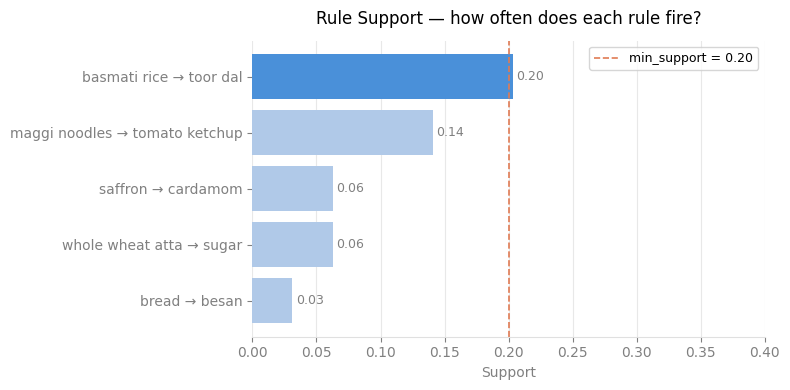

In [8]:
import matplotlib.pyplot as plt

labels_s = [r[2] for r in rules]
supports = [support(r[0] + r[1], transactions) for r in rules]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4a90d9" if s >= 0.20 else "#b0c9e8" for s in supports]
bars = ax.barh(labels_s, supports, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Support", color="gray")
ax.set_title("Rule Support — how often does each rule fire?", pad=12)
ax.set_xlim(0, 0.40)
ax.axvline(0.20, color="#e07b54", linestyle="--", linewidth=1.2, label="min_support = 0.20")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="x", color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for bar, s in zip(bars, supports):
    ax.text(s + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{s:.2f}", va="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()


Only **basmati rice → toor dal** clears the threshold — 13 of 64 orders. The rest fire too rarely to be reliable on support alone.

## Confidence

Given a customer bought A, how often did they also buy B?

> Confidence(A → B) = Support(A & B) / Support(A)

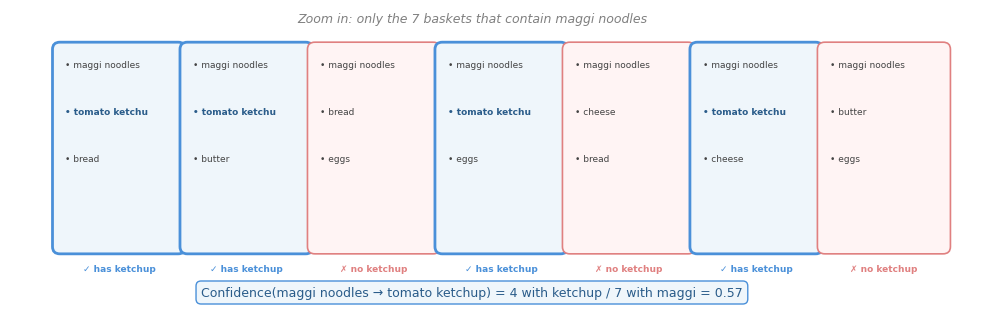

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Show only baskets that contain maggi noodles, highlight which also have ketchup
maggi_baskets = [
    (["maggi noodles", "tomato ketchup", "bread"],  True),
    (["maggi noodles", "tomato ketchup", "butter"], True),
    (["maggi noodles", "bread", "eggs"],            False),
    (["maggi noodles", "tomato ketchup", "eggs"],   True),
    (["maggi noodles", "cheese", "bread"],          False),
    (["maggi noodles", "tomato ketchup", "cheese"], True),
    (["maggi noodles", "butter", "eggs"],           False),
]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.set_xlim(-0.5, 10); ax.set_ylim(0, 3.2); ax.axis('off')

ax.text(4.5, 3.05,
        "Zoom in: only the 7 baskets that contain maggi noodles",
        ha='center', fontsize=9, color='gray', style='italic')

for i, (items, has_ketchup) in enumerate(maggi_baskets):
    x = i * 1.38
    bg     = "#EFF6FB" if has_ketchup else "#FFF4F4"
    border = "#4a90d9" if has_ketchup else "#e08080"
    lw     = 2.0 if has_ketchup else 1.2
    box = FancyBboxPatch((x + 0.04, 0.55), 1.28, 2.2,
                         boxstyle="round,pad=0.08",
                         facecolor=bg, edgecolor=border, linewidth=lw)
    ax.add_patch(box)
    for j, item in enumerate(items[:3]):
        color = '#2a5c8a' if item == 'tomato ketchup' else '#444'
        fw = 'bold' if item == 'tomato ketchup' else 'normal'
        ax.text(x + 0.1, 2.55 - j * 0.52, f"• {item[:13]}", fontsize=6.5, color=color, fontweight=fw)
    label = "✓ has ketchup" if has_ketchup else "✗ no ketchup"
    col   = "#4a90d9" if has_ketchup else "#e08080"
    ax.text(x + 0.68, 0.28, label, ha='center', fontsize=6.5, color=col, fontweight='bold')

ax.text(4.5, 0.0,
        "Confidence(maggi noodles → tomato ketchup) = 4 with ketchup / 7 with maggi = 0.57",
        ha='center', fontsize=9, color='#2a5c8a',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EFF6FB', edgecolor='#4a90d9'))
plt.tight_layout()
plt.show()


In [10]:
def confidence(A, B, transactions):
    return support(A + B, transactions) / support(A, transactions)

print(f"{'Rule':<45} {'Confidence':>10}")
print("-" * 57)
for A, B, label in rules:
    c = confidence(A, B, transactions)
    print(f"{label:<45} {c:>10.2f}")


Rule                                          Confidence
---------------------------------------------------------
basmati rice → toor dal                             0.87
maggi noodles → tomato ketchup                      0.82
saffron → cardamom                                  1.00
whole wheat atta → sugar                            0.31
bread → besan                                       0.08


In [11]:
def lift(A, B, transactions):
    return confidence(A, B, transactions) / support(B, transactions)

Confidence across the five rules:

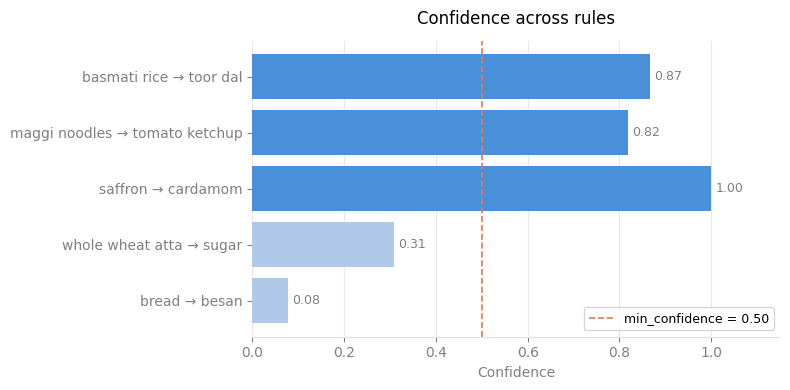

In [12]:
labels_c = [r[2] for r in rules]
confs_c  = [confidence(r[0], r[1], transactions) for r in rules]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4a90d9" if c >= 0.5 else "#b0c9e8" for c in confs_c]
bars = ax.barh(labels_c, confs_c, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Confidence", color="gray")
ax.set_title("Confidence across rules", pad=12)
ax.set_xlim(0, 1.15)
ax.axvline(0.5, color="#e07b54", linestyle="--", linewidth=1.2, label="min_confidence = 0.50")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="x", color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for bar, c in zip(bars, confs_c):
    ax.text(c + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{c:.2f}", va="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()


**Saffron → cardamom** scores 1.00 — every saffron buyer also bought cardamom — but support is low so it rarely fires. **Bread → besan** is weak on both.

## Lift

Is the association genuine, or just two popular items coincidentally appearing together?

> Lift(A → B) = Confidence(A → B) / Support(B)

- **Lift > 1** — real positive association
- **Lift = 1** — independent, no relationship
- **Lift < 1** — negative association

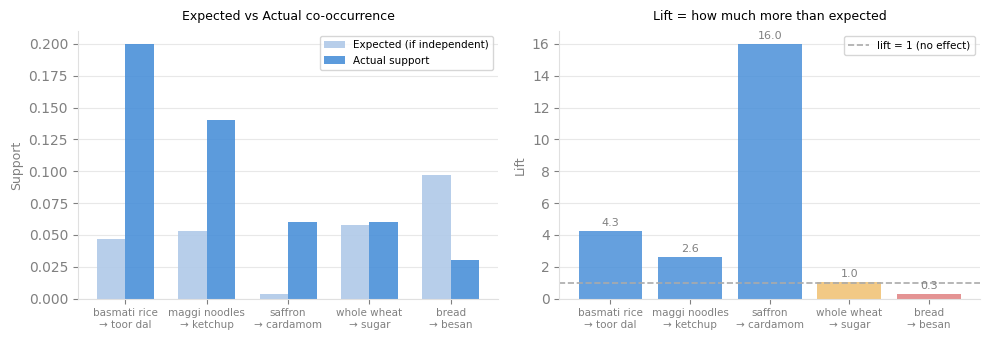

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Side-by-side comparison: expected vs actual co-occurrence
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

rules_data = [
    ("basmati rice\n→ toor dal",   0.20, 0.87, 4.27),
    ("maggi noodles\n→ ketchup",   0.14, 0.82, 2.62),
    ("saffron\n→ cardamom",        0.06, 1.00, 16.0),
    ("whole wheat\n→ sugar",       0.06, 0.31, 1.04),
    ("bread\n→ besan",             0.03, 0.08, 0.31),
]
labels_l = [r[0] for r in rules_data]
expected = [support([r[0].split('\n')[0].strip()], transactions) *
            support([r[0].split('\n')[1].replace('→ ','').strip()], transactions)
            if False else r[1] / r[3]   # support_B = conf/lift
            for r in rules_data]
actual   = [r[1] for r in rules_data]   # support of pair
lifts_l  = [r[3] for r in rules_data]

x = np.arange(len(labels_l))
w = 0.35

# Left: expected vs actual support
ax = axes[0]
ax.bar(x - w/2, expected, w, label="Expected (if independent)", color="#b0c9e8", alpha=0.9)
ax.bar(x + w/2, actual,   w, label="Actual support",            color="#4a90d9", alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels_l, fontsize=7.5)
ax.set_ylabel("Support", color="gray", fontsize=9)
ax.set_title("Expected vs Actual co-occurrence", fontsize=9, pad=8)
ax.legend(fontsize=7.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0"); ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="y", color="#e8e8e8"); ax.set_axisbelow(True)
ax.tick_params(colors="gray")

# Right: lift values
ax2 = axes[1]
colors_l = ["#4a90d9" if l > 1.5 else "#f0c070" if l >= 1.0 else "#e08080" for l in lifts_l]
ax2.bar(x, lifts_l, color=colors_l, alpha=0.85)
ax2.axhline(1.0, color="#aaaaaa", linestyle="--", linewidth=1.2, label="lift = 1 (no effect)")
ax2.set_xticks(x); ax2.set_xticklabels(labels_l, fontsize=7.5)
ax2.set_ylabel("Lift", color="gray", fontsize=9)
ax2.set_title("Lift = how much more than expected", fontsize=9, pad=8)
ax2.legend(fontsize=7.5)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#e0e0e0"); ax2.spines["bottom"].set_color("#e0e0e0")
ax2.grid(axis="y", color="#e8e8e8"); ax2.set_axisbelow(True)
ax2.tick_params(colors="gray")
for xi, l in zip(x, lifts_l):
    ax2.text(xi, l + 0.3, f"{l:.1f}", ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()


All three metrics side by side:

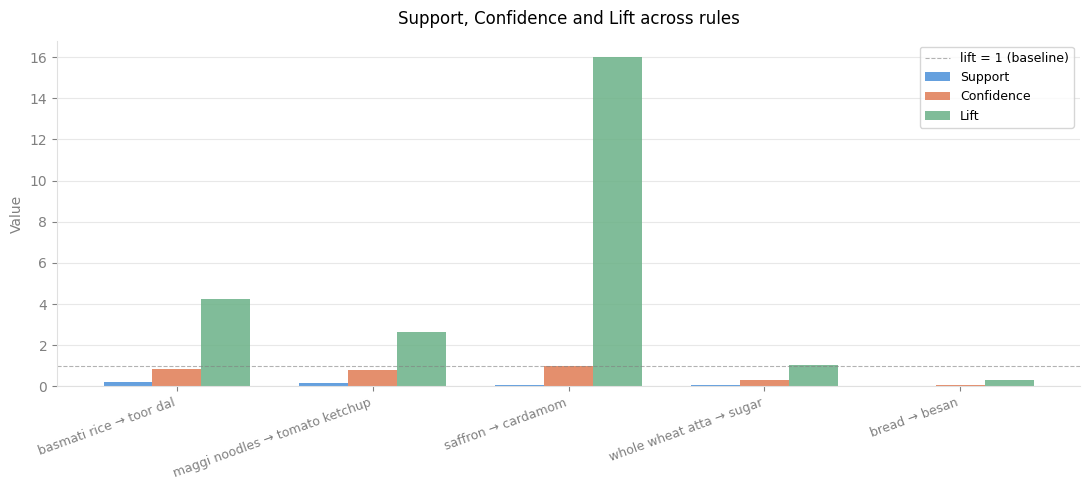

In [14]:
import numpy as np

rule_labels = [r[2] for r in rules]
supports = [support(r[0] + r[1], transactions) for r in rules]
confs    = [confidence(r[0], r[1], transactions) for r in rules]
lifts    = [lift(r[0], r[1], transactions) for r in rules]

x = np.arange(len(rule_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, supports, width, label="Support",    color="#4a90d9", alpha=0.85)
ax.bar(x,         confs,    width, label="Confidence", color="#e07b54", alpha=0.85)
ax.bar(x + width, lifts,    width, label="Lift",       color="#6ab187", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(rule_labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Value", color="gray")
ax.set_title("Support, Confidence and Lift across rules", pad=12)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="lift = 1 (baseline)")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0")
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="y", color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
plt.tight_layout()
plt.show()


Support vs Confidence, bubble size = lift — strong rules sit top-right with large bubbles:

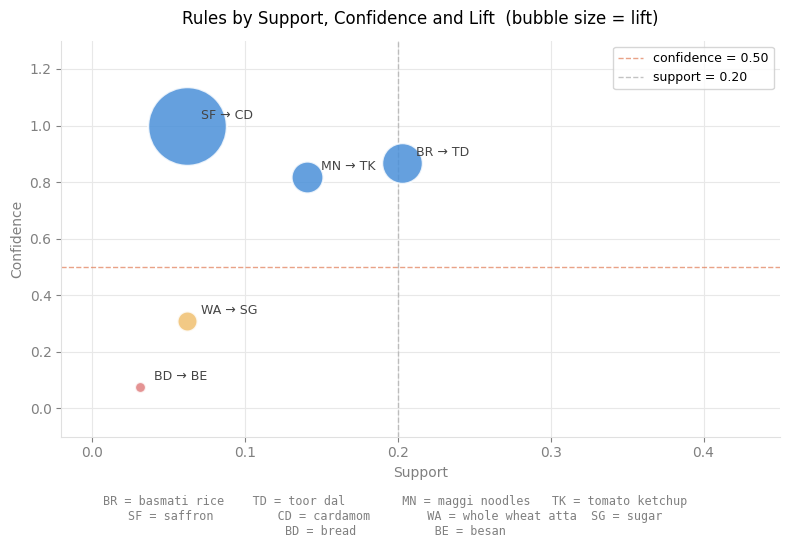

In [15]:
rule_codes = {
    "basmati rice → toor dal":        "BR → TD",
    "maggi noodles → tomato ketchup": "MN → TK",
    "saffron → cardamom":             "SF → CD",
    "whole wheat atta → sugar":       "WA → SG",
    "bread → besan":                  "BD → BE",
}

rule_data = []
for A, B, label in rules:
    s = support(A + B, transactions)
    c = confidence(A, B, transactions)
    l = lift(A, B, transactions)
    rule_data.append((rule_codes[label], s, c, l))

fig, ax = plt.subplots(figsize=(8, 5))
for code, s, c, l in rule_data:
    color = "#4a90d9" if l > 1.5 else ("#f0c070" if l >= 1.0 else "#e08080")
    ax.scatter(s, c, s=max(l * 200, 60), c=color, alpha=0.85,
               edgecolors="white", linewidth=1.5, zorder=3)
    ax.annotate(code, (s, c), textcoords="offset points",
                xytext=(10, 5), fontsize=9, color="#444444")

ax.axhline(0.5, color="#e07b54", linestyle="--", linewidth=1, alpha=0.7, label="confidence = 0.50")
ax.axvline(0.20, color="#aaaaaa", linestyle="--", linewidth=1, alpha=0.7, label="support = 0.20")
ax.set_xlabel("Support", color="gray")
ax.set_ylabel("Confidence", color="gray")
ax.set_title("Rules by Support, Confidence and Lift  (bubble size = lift)", pad=12)
ax.set_xlim(-0.02, 0.45)
ax.set_ylim(-0.1, 1.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0")
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
ax.legend(fontsize=9)

key_lines = [
    "BR = basmati rice    TD = toor dal        MN = maggi noodles   TK = tomato ketchup",
    "SF = saffron         CD = cardamom        WA = whole wheat atta  SG = sugar",
    "BD = bread           BE = besan",
]
fig.text(0.5, -0.08, "\n".join(key_lines),
         ha="center", fontsize=8.5, color="gray", family="monospace")
plt.tight_layout()
plt.show()


## Choosing the right rule

| Profile | Support | Confidence | Lift | Action |
|---|---|---|---|---|
| **Strong** | High | High | > 1 | Bundle deal, shelf placement |
| **Niche** | Low | High | > 1 | Targeted promotion |
| **Spurious** | Any | High | ≈ 1 | Ignore — popularity coincidence |
| **Dead** | Low | Low | < 1 | Discard |

Our five rules:

| Rule | Profile | Recommendation |
|---|---|---|
| basmati rice → toor dal | **Strong** (sup 0.20, conf 0.87, lift 4.27) | Combo deal |
| maggi noodles → tomato ketchup | **Strong** (sup 0.14, conf 0.82, lift 2.62) | "Bought together" nudge |
| saffron → cardamom | **Niche** (sup 0.06, conf 1.00, lift 16.0) | Target saffron buyers |
| whole wheat atta → sugar | **Spurious** (sup 0.06, conf 0.31, lift 1.04) | Ignore |
| bread → besan | **Dead** (sup 0.03, conf 0.08, lift 0.31) | Discard |

Practical thresholds: **lift > 1.5**, **confidence > 0.5**, **support > 0.05**.

---
# Part 3: Apriori

# Association Rule Mining — Part 3
### The Apriori Algorithm

In Part 2 we hand-picked five rules and computed their metrics manually. With hundreds of products that's impossible. **Apriori** automates it — scanning all transactions, finding every frequent itemset, and ranking all valid rules.

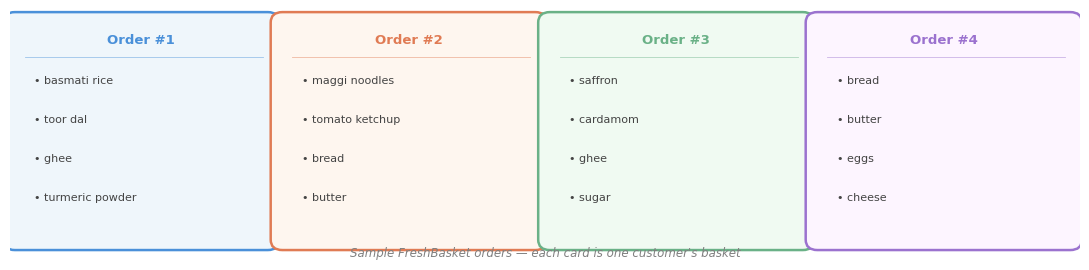

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.set_xlim(0, 11); ax.set_ylim(0, 2.8); ax.axis('off')

orders = [
    ("Order #1", ["basmati rice", "toor dal", "ghee", "turmeric powder"], "#EFF6FB", "#4a90d9"),
    ("Order #2", ["maggi noodles", "tomato ketchup", "bread", "butter"],  "#FEF6EF", "#e07b54"),
    ("Order #3", ["saffron", "cardamom", "ghee", "sugar"],                "#F0FAF2", "#6ab187"),
    ("Order #4", ["bread", "butter", "eggs", "cheese"],                   "#FDF5FF", "#9b72cf"),
]

for i, (label, items, bg, border) in enumerate(orders):
    x = i * 2.75
    box = FancyBboxPatch((x + 0.05, 0.15), 2.6, 2.5,
                         boxstyle="round,pad=0.12",
                         facecolor=bg, edgecolor=border, linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + 1.35, 2.45, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=border)
    ax.axhline(y=2.25, xmin=(x+0.15)/11, xmax=(x+2.6)/11,
               color=border, linewidth=0.6, alpha=0.5)
    for j, item in enumerate(items):
        ax.text(x + 0.25, 1.95 - j * 0.45, f"• {item}", fontsize=8, color='#444')

ax.text(5.5, -0.05, "Sample FreshBasket orders — each card is one customer's basket",
        ha='center', fontsize=8.5, color='gray', style='italic')
plt.tight_layout()
plt.show()


## Transactions

Same 64 FreshBasket orders from Part 2.

In [17]:
transactions = [
    ["basmati rice", "toor dal", "ghee", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "mustard seeds"],
    ["basmati rice", "toor dal", "ghee", "mustard seeds"],
    ["basmati rice", "toor dal", "turmeric powder", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "besan"],
    ["basmati rice", "toor dal", "mustard seeds", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "ghee"],
    ["basmati rice", "toor dal", "turmeric powder", "besan"],
    ["basmati rice", "toor dal", "ghee", "refined oil"],
    ["basmati rice", "toor dal", "mustard seeds", "besan"],
    ["basmati rice", "toor dal", "turmeric powder", "mustard seeds"],
    ["basmati rice", "toor dal", "besan", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "refined oil", "besan", "turmeric powder"],
    ["maggi noodles", "tomato ketchup", "butter", "bread"],
    ["maggi noodles", "tomato ketchup", "eggs", "bread"],
    ["maggi noodles", "tomato ketchup", "cheese", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "eggs"],
    ["maggi noodles", "tomato ketchup", "butter", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "cheese"],
    ["maggi noodles", "tomato ketchup", "bread", "butter"],
    ["maggi noodles", "butter", "bread", "eggs"],
    ["maggi noodles", "cheese", "eggs", "bread"],
    ["tomato ketchup", "bread", "butter", "eggs"],
    ["tomato ketchup", "cheese", "bread", "butter"],
    ["tomato ketchup", "eggs", "cheese", "bread"],
    ["tomato ketchup", "butter", "bread", "sugar"],
    ["tomato ketchup", "bread", "eggs", "sugar"],
    ["tomato ketchup", "cheese", "butter", "sugar"],
    ["tomato ketchup", "eggs", "butter", "sugar"],
    ["tomato ketchup", "bread", "cheese", "sugar"],
    ["tomato ketchup", "butter", "eggs", "sugar"],
    ["tomato ketchup", "bread", "butter", "cheese"],
    ["saffron", "cardamom", "ghee", "sugar"],
    ["saffron", "cardamom", "sugar", "whole wheat atta"],
    ["saffron", "cardamom", "ghee", "whole wheat atta"],
    ["saffron", "cardamom", "sugar", "ghee"],
    ["whole wheat atta", "besan", "refined oil", "ghee"],
    ["whole wheat atta", "besan", "mustard seeds", "refined oil"],
    ["whole wheat atta", "besan", "ghee", "turmeric powder"],
    ["whole wheat atta", "sugar", "ghee", "butter"],
    ["whole wheat atta", "sugar", "eggs", "butter"],
    ["whole wheat atta", "besan", "refined oil", "mustard seeds"],
    ["whole wheat atta", "ghee", "besan", "turmeric powder"],
    ["whole wheat atta", "ghee", "refined oil", "mustard seeds"],
    ["whole wheat atta", "besan", "turmeric powder", "mustard seeds"],
    ["sugar", "butter", "eggs", "bread"],
    ["sugar", "butter", "bread", "cheese"],
    ["sugar", "ghee", "eggs", "bread"],
    ["bread", "butter", "eggs", "sugar"],
    ["bread", "butter", "cheese", "eggs"],
    ["bread", "eggs", "butter", "whole wheat atta"],
    ["bread", "cheese", "butter", "sugar"],
    ["bread", "eggs", "whole wheat atta", "sugar"],
    ["bread", "tomato ketchup", "butter", "eggs"],
    ["bread", "besan", "butter", "eggs"],
    ["bread", "besan", "ghee", "sugar"],
    ["bread", "cheese", "sugar", "butter"],
    ["besan", "ghee", "refined oil", "turmeric powder"],
    ["besan", "refined oil", "mustard seeds", "ghee"],
    ["besan", "ghee", "turmeric powder", "mustard seeds"],
]

print(f"Transactions : {len(transactions)}")
print(f"Unique items : {len(set(i for t in transactions for i in t))}")


Transactions : 64
Unique items : 17


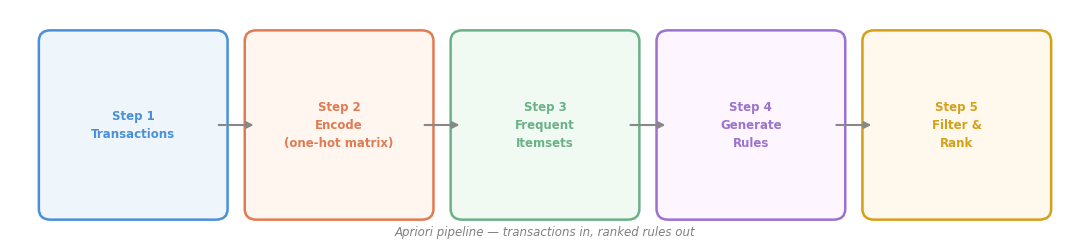

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.set_xlim(0, 11); ax.set_ylim(0, 2.6); ax.axis('off')

steps = [
    ("Step 1\nTransactions", "#EFF6FB", "#4a90d9"),
    ("Step 2\nEncode\n(one-hot matrix)", "#FEF6EF", "#e07b54"),
    ("Step 3\nFrequent\nItemsets", "#F0FAF2", "#6ab187"),
    ("Step 4\nGenerate\nRules", "#FDF5FF", "#9b72cf"),
    ("Step 5\nFilter &\nRank", "#FFF8EC", "#d4a017"),
]

box_w, box_h = 1.7, 1.9
gap = (11 - len(steps) * box_w) / (len(steps) + 1)

positions = []
for i, (label, bg, border) in enumerate(steps):
    x = gap + i * (box_w + gap)
    y = 0.35
    box = FancyBboxPatch((x, y), box_w, box_h,
                         boxstyle="round,pad=0.12",
                         facecolor=bg, edgecolor=border, linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + box_w / 2, y + box_h / 2, label,
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=border, linespacing=1.5)
    positions.append((x, y, box_w, box_h))

for i in range(len(positions) - 1):
    x1 = positions[i][0] + positions[i][2]
    x2 = positions[i+1][0]
    yc = positions[i][1] + positions[i][3] / 2
    ax.annotate("", xy=(x2, yc), xytext=(x1, yc),
                arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.5))

ax.text(5.5, 0.05, "Apriori pipeline — transactions in, ranked rules out",
        ha='center', fontsize=8.5, color='gray', style='italic')
plt.tight_layout()
plt.show()


## How Apriori works

**Step 1 — Frequent itemsets:** counts item frequencies, discards anything below `min_support`, then combines survivors into pairs, triples, etc. Any itemset below the threshold is pruned along with all its supersets — the **anti-monotone property**.

**Step 2 — Generate rules:** splits each frequent itemset into all possible if-then rules, drops those below `min_confidence`, ranks the rest.

## Step 1 — Encode

One-hot matrix: one row per order, one column per item, `True` if present.

In [19]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {df.shape}  ({df.shape[0]} orders × {df.shape[1]} items)")
df.head()


Matrix shape: (64, 17)  (64 orders × 17 items)


,basmati rice,besan,bread,butter,cardamom,cheese,eggs,ghee,maggi noodles,mustard seeds,refined oil,saffron,sugar,tomato ketchup,toor dal,turmeric powder,whole wheat atta
0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False
1,True,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False
2,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False
3,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False
4,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False


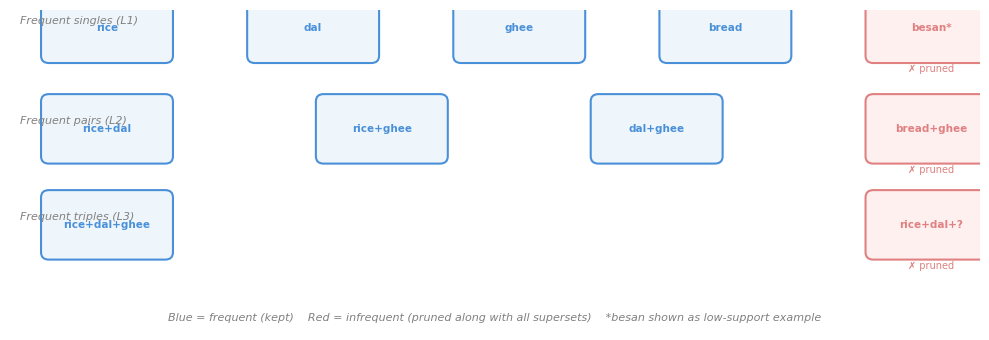

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 3.5); ax.axis('off')

# Level 1: singles
singles = [("rice", True), ("dal", True), ("ghee", True), ("bread", True), ("besan*", False)]
# Level 2: pairs (pruned if either parent infrequent)
pairs = [("rice+dal", True), ("rice+ghee", True), ("dal+ghee", True), ("bread+ghee", False)]
# Level 3: triples
triples = [("rice+dal+ghee", True), ("rice+dal+?", False)]

levels = [
    (singles, 3.0, "Frequent singles (L1)"),
    (pairs,   1.9, "Frequent pairs (L2)"),
    (triples, 0.85, "Frequent triples (L3)"),
]

for items, y, level_label in levels:
    n = len(items)
    xs = [1 + i * (8.5 / max(n-1,1)) for i in range(n)]
    ax.text(0.1, y + 0.35, level_label, fontsize=8, color='gray', style='italic')
    for x, (label, freq) in zip(xs, items):
        bg = "#EFF6FB" if freq else "#FFF0F0"
        border = "#4a90d9" if freq else "#e08080"
        box = FancyBboxPatch((x - 0.6, y), 1.2, 0.6,
                             boxstyle="round,pad=0.08",
                             facecolor=bg, edgecolor=border, linewidth=1.5)
        ax.add_patch(box)
        ax.text(x, y + 0.3, label, ha='center', va='center',
                fontsize=7.5, color=border, fontweight='bold')
        if not freq:
            ax.text(x, y - 0.18, "✗ pruned", ha='center', fontsize=7, color='#e08080')

ax.text(5, 0.1, "Blue = frequent (kept)    Red = infrequent (pruned along with all supersets)    *besan shown as low-support example",
        ha='center', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.show()


## Step 2 — Mine frequent itemsets

`min_support = 0.05` → itemset must appear in ≥ 5% of orders (≥ 4 of 64).

In [21]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(['length', 'support'], ascending=[True, False])

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print()
print(frequent_itemsets.groupby('length')['support'].agg(['count','min','max'])
      .rename(columns={'count':'itemsets','min':'min support','max':'max support'}))


Total frequent itemsets found: 89

        itemsets  min support  max support
length                                    
1             17       0.0625      0.40625
2             47       0.0625      0.25000
3             25       0.0625      0.12500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Frequent combinations drop at each level — infrequent subsets prune all their supersets automatically.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

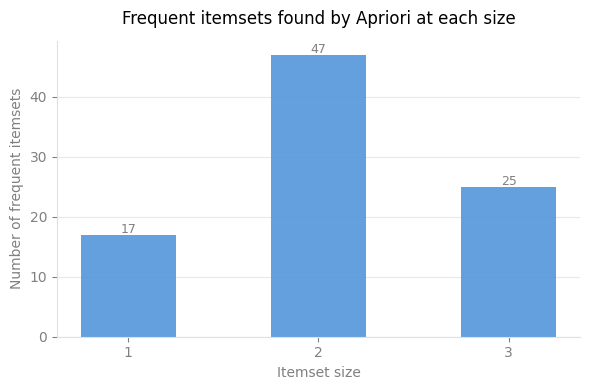

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
import matplotlib.pyplot as plt

size_counts = frequent_itemsets.groupby('length').size()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(size_counts.index, size_counts.values, color="#4a90d9", alpha=0.85, width=0.5)
ax.set_xlabel("Itemset size", color="gray")
ax.set_ylabel("Number of frequent itemsets", color="gray")
ax.set_title("Frequent itemsets found by Apriori at each size", pad=12)
ax.set_xticks(size_counts.index)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0")
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="y", color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for i, v in zip(size_counts.index, size_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()


Top 10 most frequent itemsets:

In [23]:
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(10).copy()
top_itemsets['itemsets'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(x)))
top_itemsets[['itemsets', 'length', 'support']].reset_index(drop=True)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,itemsets,length,support
0,bread,1,0.406250
1,butter,1,0.375000
2,eggs,1,0.312500
3,ghee,1,0.312500
4,tomato ketchup,1,0.312500
5,sugar,1,0.296875
6,besan,1,0.250000
7,"bread, butter",2,0.250000
8,basmati rice,1,0.234375
9,"bread, eggs",2,0.234375


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 3 — Generate rules

Every frequent itemset is split into all possible if-then rules. We keep only those with lift ≥ 1.0.

In [24]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules generated: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rules generated: 240


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,cardamom,saffron,0.062500,1.000000,16.000000
1,saffron,cardamom,0.062500,1.000000,16.000000
2,basmati rice,toor dal,0.203125,0.866667,4.266667
3,toor dal,basmati rice,0.203125,1.000000,4.266667
4,basmati rice,"ghee, toor dal",0.093750,0.400000,4.266667
5,"ghee, toor dal",basmati rice,0.093750,1.000000,4.266667
6,"mustard seeds, toor dal",basmati rice,0.093750,1.000000,4.266667
7,basmati rice,"mustard seeds, toor dal",0.093750,0.400000,4.266667
8,basmati rice,"refined oil, toor dal",0.078125,0.333333,4.266667
9,"besan, toor dal",basmati rice,0.062500,1.000000,4.266667


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 4 — Filter

Practical filter for actionable rules:
- **support ≥ 0.05** — fires often enough
- **confidence ≥ 0.50** — reliable when it fires
- **lift ≥ 1.5** — genuine association

In [25]:
strong_rules = rules[
    (rules['support']    >= 0.05) &
    (rules['confidence'] >= 0.50) &
    (rules['lift']       >= 1.50)
].reset_index(drop=True)

print(f"Strong rules after filtering: {len(strong_rules)}")
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Strong rules after filtering: 65


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,cardamom,saffron,0.062500,1.000000,16.000000
1,saffron,cardamom,0.062500,1.000000,16.000000
2,basmati rice,toor dal,0.203125,0.866667,4.266667
3,toor dal,basmati rice,0.203125,1.000000,4.266667
4,"ghee, toor dal",basmati rice,0.093750,1.000000,4.266667
...,...,...,...,...,...
60,eggs,butter,0.187500,0.600000,1.600000
61,"bread, cheese",butter,0.093750,0.600000,1.600000
62,maggi noodles,bread,0.109375,0.636364,1.566434
63,sugar,butter,0.171875,0.578947,1.543860


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Visualising rules

Top-right bubbles with large size = strongest rules (high support, confidence, and lift):

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

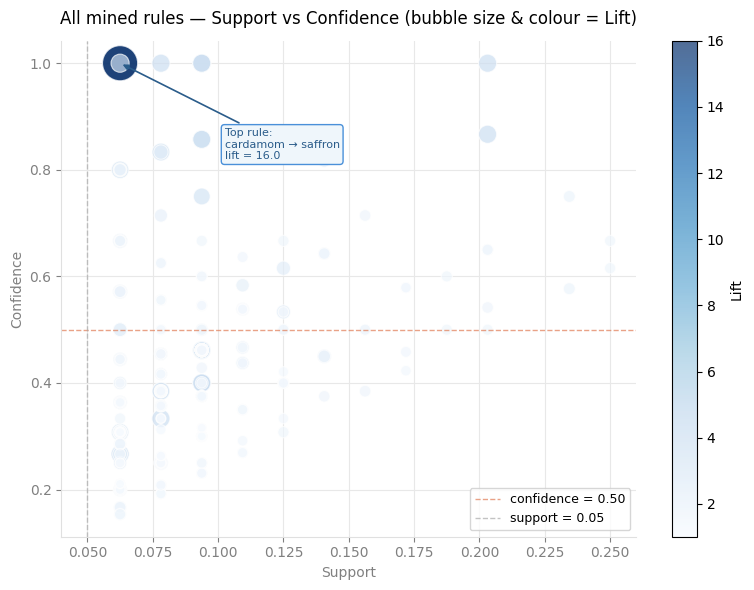

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    rules['support'], rules['confidence'],
    s=rules['lift'] * 40, c=rules['lift'],
    cmap='Blues', alpha=0.7, edgecolors='white', linewidth=0.8
)
plt.colorbar(scatter, ax=ax, label="Lift")

ax.axhline(0.5, color="#e07b54", linestyle="--", linewidth=1, alpha=0.7, label="confidence = 0.50")
ax.axvline(0.05, color="#aaaaaa", linestyle="--", linewidth=1, alpha=0.7, label="support = 0.05")
ax.set_xlabel("Support", color="gray")
ax.set_ylabel("Confidence", color="gray")
ax.set_title("All mined rules — Support vs Confidence (bubble size & colour = Lift)", pad=12)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0")
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")

# Annotate top rule by lift
top_rule = rules.iloc[0]
ax.annotate(
    f"Top rule:\n{top_rule['antecedents']} → {top_rule['consequents']}\n"
    f"lift = {top_rule['lift']:.1f}",
    xy=(top_rule['support'], top_rule['confidence']),
    xytext=(top_rule['support'] + 0.04, top_rule['confidence'] - 0.18),
    fontsize=8, color="#2a5c8a",
    arrowprops=dict(arrowstyle="-|>", color="#2a5c8a", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#EFF6FB", edgecolor="#4a90d9", linewidth=1)
)

plt.tight_layout()
plt.show()


### Top 10 by lift

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

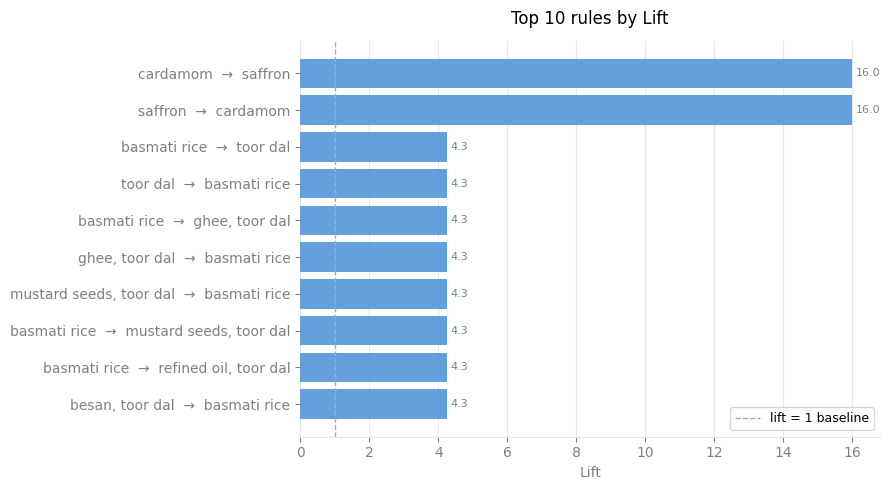

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [27]:
top10 = rules.head(10).copy()
top10['rule'] = top10['antecedents'] + '  →  ' + top10['consequents']

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4a90d9" if l > 4 else "#6ab187" if l > 2 else "#f0c070" for l in top10['lift']]
ax.barh(top10['rule'], top10['lift'], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("Lift", color="gray")
ax.set_title("Top 10 rules by Lift", pad=12)
ax.axvline(1.0, color="#aaaaaa", linestyle="--", linewidth=1, label="lift = 1 baseline")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="x", color="#e8e8e8", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['lift'] + 0.1, i, f"{row['lift']:.1f}", va="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## Connecting back to Part 2

The five hand-picked rules from Part 2 are extracted below from Apriori's output — values match exactly, confirming Apriori runs the same calculation across every combination automatically.

In [28]:
target_rules = [
    ("basmati rice", "toor dal"),
    ("maggi noodles", "tomato ketchup"),
    ("saffron", "cardamom"),
    ("whole wheat atta", "sugar"),
    ("bread", "besan"),
]

print(f"{'Rule':<45} {'Support':>8} {'Confidence':>11} {'Lift':>7}")
print("-" * 75)
for ant, con in target_rules:
    match = rules[
        (rules['antecedents'] == ant) &
        (rules['consequents'] == con)
    ]
    if not match.empty:
        row = match.iloc[0]
        print(f"{ant + ' → ' + con:<45} {row['support']:>8.2f} {row['confidence']:>11.2f} {row['lift']:>7.2f}")
    else:
        print(f"{ant + ' → ' + con:<45} {'not found (below threshold)':>27}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rule                                           Support  Confidence    Lift
---------------------------------------------------------------------------
basmati rice → toor dal                           0.20        0.87    4.27
maggi noodles → tomato ketchup                    0.14        0.82    2.62
saffron → cardamom                                0.06        1.00   16.00
whole wheat atta → sugar                          0.06        0.31    1.04
bread → besan                                 not found (below threshold)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

We checked 5 rules manually. Apriori checked all possible combinations and found every meaningful pattern in one pass.

## Key parameters

| Parameter | Effect | Starting point |
|---|---|---|
| `min_support` | Lower → more itemsets, slower | 0.05 – 0.10 |
| `min_confidence` | Lower → more rules, more noise | 0.50 |
| `min_threshold` (lift) | Filters genuine associations | 1.5 |

Start high on `min_support` and lower only if too few rules appear.

---
# Part 4: FP-Growth

# Association Rule Mining — Part 4
### FP-Growth Algorithm

Apriori makes multiple database passes and generates many candidate itemsets. **FP-Growth** avoids both — it compresses all transactions into an **FP-Tree** and mines patterns directly from it, with no candidate generation.

## How FP-Growth works

**Scan 1** — Count frequencies, discard items below `min_support`, sort survivors descending.

**Scan 2** — Insert each transaction into the tree. Shared prefixes are merged, making the tree far smaller than the raw data.

Mining works backwards: for each item, FP-Growth extracts its **conditional pattern base** (all paths ending at that item) and builds a smaller sub-tree. Frequent patterns emerge recursively — no candidates ever generated.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

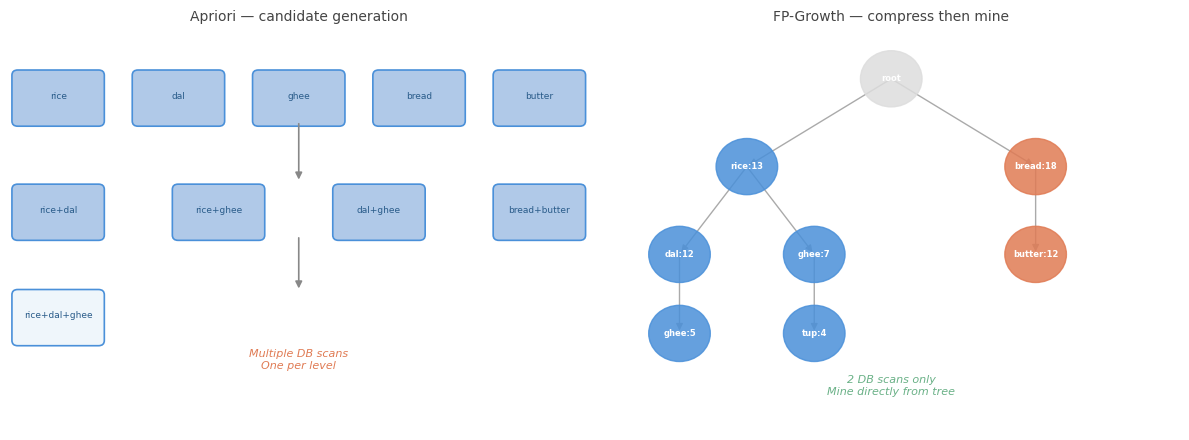

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: Apriori approach ─────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 6); ax.set_ylim(0, 4.5); ax.axis('off')
ax.set_title("Apriori — candidate generation", fontsize=10, pad=10, color='#444')

levels = [
    (["rice", "dal", "ghee", "bread", "butter"], 3.8, "#b0c9e8", "#4a90d9"),
    (["rice+dal", "rice+ghee", "dal+ghee", "bread+butter"], 2.5, "#b0c9e8", "#4a90d9"),
    (["rice+dal+ghee"], 1.3, "#EFF6FB", "#4a90d9"),
]
for items, y, bg, border in levels:
    n = len(items)
    xs = [0.5 + i * (5.0 / max(n-1,1)) for i in range(n)]
    for x, item in zip(xs, items):
        box = FancyBboxPatch((x-0.42, y-0.28), 0.84, 0.52,
                             boxstyle="round,pad=0.06", facecolor=bg, edgecolor=border, linewidth=1.2)
        ax.add_patch(box)
        ax.text(x, y, item, ha='center', va='center', fontsize=6.5, color='#2a5c8a')

ax.annotate("", xy=(3, 2.82), xytext=(3, 3.52),
            arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.2))
ax.annotate("", xy=(3, 1.58), xytext=(3, 2.22),
            arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.2))
ax.text(3, 0.7, "Multiple DB scans\nOne per level", ha='center', fontsize=8,
        color='#e07b54', style='italic')

# ── Right: FP-Growth approach ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 6); ax2.set_ylim(0, 4.5); ax2.axis('off')
ax2.set_title("FP-Growth — compress then mine", fontsize=10, pad=10, color='#444')

nodes = {
    "root":  (3.0, 4.0),
    "rice":  (1.5, 3.0), "bread": (4.5, 3.0),
    "dal":   (0.8, 2.0), "ghee":  (2.2, 2.0), "butter": (4.5, 2.0),
    "ghee2": (0.8, 1.1), "tup":   (2.2, 1.1),
}
edges = [("root","rice"),("root","bread"),("rice","dal"),("rice","ghee"),
         ("dal","ghee2"),("ghee","tup"),("bread","butter")]
labels = {"root":"root","rice":"rice:13","bread":"bread:18",
          "dal":"dal:12","ghee":"ghee:7","butter":"butter:12",
          "ghee2":"ghee:5","tup":"tup:4"}
colors_n = {"root":"#ddd","rice":"#4a90d9","bread":"#e07b54",
            "dal":"#4a90d9","ghee":"#4a90d9","butter":"#e07b54",
            "ghee2":"#4a90d9","tup":"#4a90d9"}

for a, b in edges:
    x1,y1 = nodes[a]; x2,y2 = nodes[b]
    ax2.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="-|>", color="#aaa", lw=1.0))
for key, (x,y) in nodes.items():
    circle = plt.Circle((x,y), 0.32, color=colors_n[key], zorder=3, alpha=0.85)
    ax2.add_patch(circle)
    ax2.text(x, y, labels[key], ha='center', va='center', fontsize=6, color='white', fontweight='bold')

ax2.text(3, 0.4, "2 DB scans only\nMine directly from tree",
         ha='center', fontsize=8, color='#6ab187', style='italic')

plt.tight_layout()
plt.show()


## Transactions

Same 64 FreshBasket orders as Parts 2 and 3.

In [30]:
transactions = [
    ["basmati rice", "toor dal", "ghee", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "mustard seeds"],
    ["basmati rice", "toor dal", "ghee", "mustard seeds"],
    ["basmati rice", "toor dal", "turmeric powder", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "besan"],
    ["basmati rice", "toor dal", "mustard seeds", "turmeric powder"],
    ["basmati rice", "toor dal", "refined oil", "ghee"],
    ["basmati rice", "toor dal", "turmeric powder", "besan"],
    ["basmati rice", "toor dal", "ghee", "refined oil"],
    ["basmati rice", "toor dal", "mustard seeds", "besan"],
    ["basmati rice", "toor dal", "turmeric powder", "mustard seeds"],
    ["basmati rice", "toor dal", "besan", "refined oil"],
    ["basmati rice", "toor dal", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "ghee", "turmeric powder", "mustard seeds"],
    ["basmati rice", "refined oil", "besan", "turmeric powder"],
    ["maggi noodles", "tomato ketchup", "butter", "bread"],
    ["maggi noodles", "tomato ketchup", "eggs", "bread"],
    ["maggi noodles", "tomato ketchup", "cheese", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "butter"],
    ["maggi noodles", "tomato ketchup", "bread", "eggs"],
    ["maggi noodles", "tomato ketchup", "butter", "cheese"],
    ["maggi noodles", "tomato ketchup", "eggs", "cheese"],
    ["maggi noodles", "tomato ketchup", "bread", "butter"],
    ["maggi noodles", "butter", "bread", "eggs"],
    ["maggi noodles", "cheese", "eggs", "bread"],
    ["tomato ketchup", "bread", "butter", "eggs"],
    ["tomato ketchup", "cheese", "bread", "butter"],
    ["tomato ketchup", "eggs", "cheese", "bread"],
    ["tomato ketchup", "butter", "bread", "sugar"],
    ["tomato ketchup", "bread", "eggs", "sugar"],
    ["tomato ketchup", "cheese", "butter", "sugar"],
    ["tomato ketchup", "eggs", "butter", "sugar"],
    ["tomato ketchup", "bread", "cheese", "sugar"],
    ["tomato ketchup", "butter", "eggs", "sugar"],
    ["tomato ketchup", "bread", "butter", "cheese"],
    ["saffron", "cardamom", "ghee", "sugar"],
    ["saffron", "cardamom", "sugar", "whole wheat atta"],
    ["saffron", "cardamom", "ghee", "whole wheat atta"],
    ["saffron", "cardamom", "sugar", "ghee"],
    ["whole wheat atta", "besan", "refined oil", "ghee"],
    ["whole wheat atta", "besan", "mustard seeds", "refined oil"],
    ["whole wheat atta", "besan", "ghee", "turmeric powder"],
    ["whole wheat atta", "sugar", "ghee", "butter"],
    ["whole wheat atta", "sugar", "eggs", "butter"],
    ["whole wheat atta", "besan", "refined oil", "mustard seeds"],
    ["whole wheat atta", "ghee", "besan", "turmeric powder"],
    ["whole wheat atta", "ghee", "refined oil", "mustard seeds"],
    ["whole wheat atta", "besan", "turmeric powder", "mustard seeds"],
    ["sugar", "butter", "eggs", "bread"],
    ["sugar", "butter", "bread", "cheese"],
    ["sugar", "ghee", "eggs", "bread"],
    ["bread", "butter", "eggs", "sugar"],
    ["bread", "butter", "cheese", "eggs"],
    ["bread", "eggs", "butter", "whole wheat atta"],
    ["bread", "cheese", "butter", "sugar"],
    ["bread", "eggs", "whole wheat atta", "sugar"],
    ["bread", "tomato ketchup", "butter", "eggs"],
    ["bread", "besan", "butter", "eggs"],
    ["bread", "besan", "ghee", "sugar"],
    ["bread", "cheese", "sugar", "butter"],
    ["besan", "ghee", "refined oil", "turmeric powder"],
    ["besan", "refined oil", "mustard seeds", "ghee"],
    ["besan", "ghee", "turmeric powder", "mustard seeds"],
]

print(f"Transactions : {len(transactions)}")
print(f"Unique items : {len(set(i for t in transactions for i in t))}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Transactions : 64
Unique items : 17


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 1 — Encode

Same one-hot matrix as Apriori.

In [31]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {df.shape}  ({df.shape[0]} orders × {df.shape[1]} items)")
df.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Matrix shape: (64, 17)  (64 orders × 17 items)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,basmati rice,besan,bread,butter,cardamom,cheese,eggs,ghee,maggi noodles,mustard seeds,refined oil,saffron,sugar,tomato ketchup,toor dal,turmeric powder,whole wheat atta
0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False
1,True,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False
2,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False
3,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False
4,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 2 — Scan 1: item frequency order

Items are sorted descending by frequency — most frequent items sit near the root, maximising shared prefixes in the tree.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

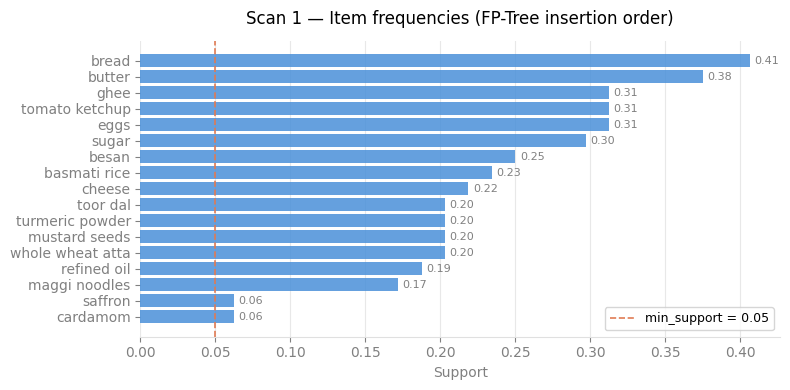

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
import matplotlib.pyplot as plt
from collections import Counter

item_counts = Counter(item for t in transactions for item in t)
min_sup_count = int(0.05 * len(transactions))  # min_support = 0.05

freq_items = {k: v for k, v in item_counts.items() if v >= min_sup_count}
freq_sorted = sorted(freq_items.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(8, 4))
items_s, counts_s = zip(*freq_sorted)
colors = ["#4a90d9" if c / len(transactions) >= 0.05 else "#b0c9e8" for c in counts_s]
bars = ax.barh(items_s, [c / len(transactions) for c in counts_s], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("Support", color="gray")
ax.set_title("Scan 1 — Item frequencies (FP-Tree insertion order)", pad=12)
ax.axvline(0.05, color="#e07b54", linestyle="--", linewidth=1.2, label="min_support = 0.05")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False); ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="x", color="#e8e8e8", linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for bar, (item, count) in zip(bars, freq_sorted):
    ax.text(count/len(transactions) + 0.003, bar.get_y() + bar.get_height()/2,
            f"{count/len(transactions):.2f}", va="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## Step 3 — Mine with FP-Growth

`fpgrowth()` builds the FP-Tree and extracts all frequent itemsets in exactly 2 database scans.

In [33]:
from mlxtend.frequent_patterns import fpgrowth

fp_itemsets = fpgrowth(df, min_support=0.05, use_colnames=True)
fp_itemsets['length'] = fp_itemsets['itemsets'].apply(len)
fp_itemsets = fp_itemsets.sort_values(['length', 'support'], ascending=[True, False])

print(f"Total frequent itemsets found: {len(fp_itemsets)}")
print()
print(fp_itemsets.groupby('length')['support'].agg(['count','min','max'])
      .rename(columns={'count':'itemsets','min':'min support','max':'max support'}))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total frequent itemsets found: 89

        itemsets  min support  max support
length                                    
1             17       0.0625      0.40625
2             47       0.0625      0.25000
3             25       0.0625      0.12500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

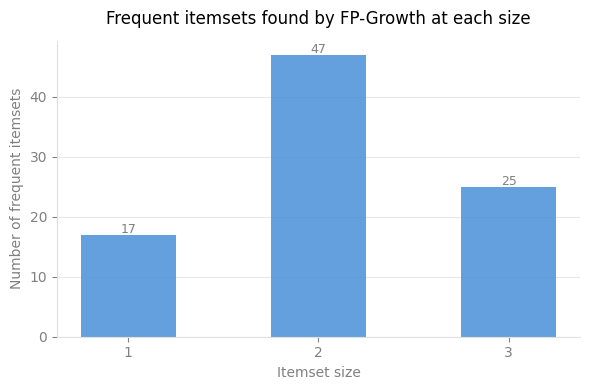

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [34]:
import matplotlib.pyplot as plt

size_counts = fp_itemsets.groupby('length').size()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(size_counts.index, size_counts.values, color="#4a90d9", alpha=0.85, width=0.5)
ax.set_xlabel("Itemset size", color="gray")
ax.set_ylabel("Number of frequent itemsets", color="gray")
ax.set_title("Frequent itemsets found by FP-Growth at each size", pad=12)
ax.set_xticks(size_counts.index)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0"); ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="y", color="#e8e8e8", linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for i, v in zip(size_counts.index, size_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()


## Step 4 — Generate rules

Identical to Apriori — only the itemset source differs.

In [35]:
from mlxtend.frequent_patterns import association_rules

fp_rules = association_rules(fp_itemsets, metric="lift", min_threshold=1.0)
fp_rules['antecedents'] = fp_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
fp_rules['consequents'] = fp_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
fp_rules = fp_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules generated: {len(fp_rules)}")
fp_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total rules generated: 240


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,saffron,cardamom,0.062500,1.000000,16.000000
1,cardamom,saffron,0.062500,1.000000,16.000000
2,basmati rice,toor dal,0.203125,0.866667,4.266667
3,toor dal,basmati rice,0.203125,1.000000,4.266667
4,basmati rice,"ghee, toor dal",0.093750,0.400000,4.266667
5,"ghee, toor dal",basmati rice,0.093750,1.000000,4.266667
6,"toor dal, turmeric powder",basmati rice,0.093750,1.000000,4.266667
7,basmati rice,"toor dal, turmeric powder",0.093750,0.400000,4.266667
8,basmati rice,"refined oil, toor dal",0.078125,0.333333,4.266667
9,"besan, toor dal",basmati rice,0.062500,1.000000,4.266667


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 5 — Filter

In [36]:
strong_rules = fp_rules[
    (fp_rules['support']    >= 0.05) &
    (fp_rules['confidence'] >= 0.50) &
    (fp_rules['lift']       >= 1.50)
].reset_index(drop=True)

print(f"Strong rules after filtering: {len(strong_rules)}")
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Strong rules after filtering: 65


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,saffron,cardamom,0.062500,1.000000,16.000000
1,cardamom,saffron,0.062500,1.000000,16.000000
2,basmati rice,toor dal,0.203125,0.866667,4.266667
3,toor dal,basmati rice,0.203125,1.000000,4.266667
4,"ghee, toor dal",basmati rice,0.093750,1.000000,4.266667
...,...,...,...,...,...
60,eggs,butter,0.187500,0.600000,1.600000
61,"bread, cheese",butter,0.093750,0.600000,1.600000
62,maggi noodles,bread,0.109375,0.636364,1.566434
63,sugar,butter,0.171875,0.578947,1.543860


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Visualising rules

Top-right bubbles with large size = strongest rules:

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

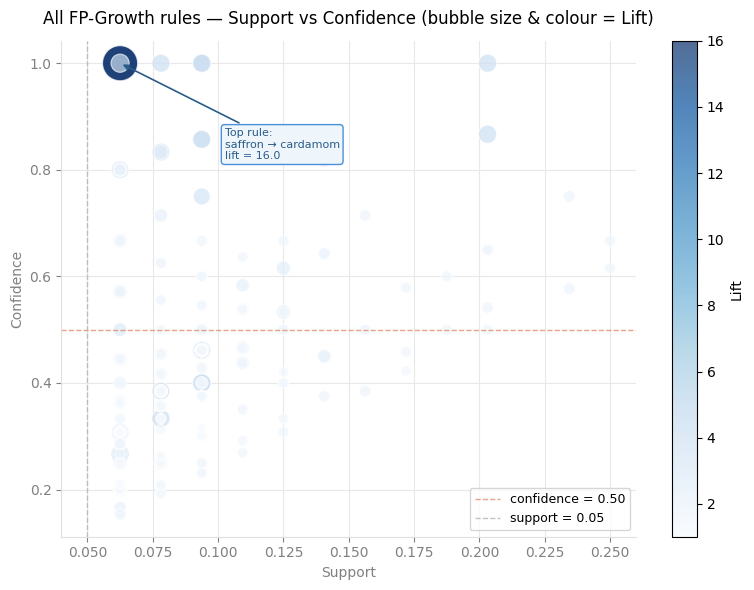

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [37]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    fp_rules['support'], fp_rules['confidence'],
    s=fp_rules['lift'] * 40, c=fp_rules['lift'],
    cmap='Blues', alpha=0.7, edgecolors='white', linewidth=0.8
)
plt.colorbar(scatter, ax=ax, label="Lift")

# Annotate top rule
top = fp_rules.iloc[0]
ax.annotate(
    f"Top rule:\n{top['antecedents']} → {top['consequents']}\nlift = {top['lift']:.1f}",
    xy=(top['support'], top['confidence']),
    xytext=(top['support'] + 0.04, top['confidence'] - 0.18),
    fontsize=8, color="#2a5c8a",
    arrowprops=dict(arrowstyle="-|>", color="#2a5c8a", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#EFF6FB", edgecolor="#4a90d9", linewidth=1)
)

ax.axhline(0.5, color="#e07b54", linestyle="--", linewidth=1, alpha=0.7, label="confidence = 0.50")
ax.axvline(0.05, color="#aaaaaa", linestyle="--", linewidth=1, alpha=0.7, label="support = 0.05")
ax.set_xlabel("Support", color="gray")
ax.set_ylabel("Confidence", color="gray")
ax.set_title("All FP-Growth rules — Support vs Confidence (bubble size & colour = Lift)", pad=12)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#e0e0e0"); ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(color="#e8e8e8", linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(colors="gray")
plt.tight_layout()
plt.show()


### Top 10 by lift

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

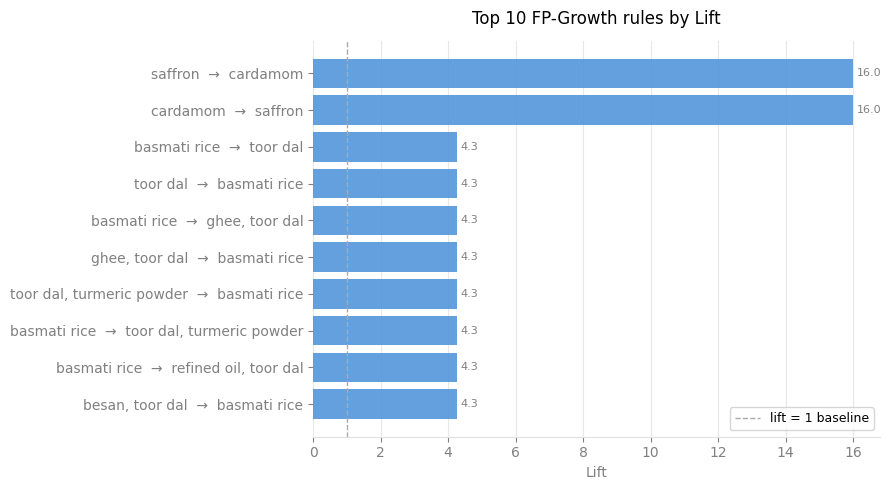

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
top10 = fp_rules.head(10).copy()
top10['rule'] = top10['antecedents'] + '  →  ' + top10['consequents']

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4a90d9" if l > 4 else "#6ab187" if l > 2 else "#f0c070" for l in top10['lift']]
ax.barh(top10['rule'], top10['lift'], color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("Lift", color="gray")
ax.set_title("Top 10 FP-Growth rules by Lift", pad=12)
ax.axvline(1.0, color="#aaaaaa", linestyle="--", linewidth=1, label="lift = 1 baseline")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False); ax.spines["bottom"].set_color("#e0e0e0")
ax.grid(axis="x", color="#e8e8e8", linewidth=0.8); ax.set_axisbelow(True)
ax.tick_params(colors="gray")
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['lift'] + 0.1, i, f"{row['lift']:.1f}", va="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## FP-Growth vs Apriori

Both find **identical** itemsets and rules. The difference is only in approach and speed.

## When to use which

| | Apriori | FP-Growth |
|---|---|---|
| **Approach** | Generate candidates | Compress to tree |
| **DB scans** | One per level | Always 2 |
| **Memory** | Low | Higher (tree in RAM) |
| **Speed** | Slower at scale | Faster on large data |
| **Results** | Identical | Identical |
| **Best for** | Small datasets | Production, large catalogues |

On 64 transactions the difference is negligible. At millions of orders and thousands of products, FP-Growth can be orders of magnitude faster.